# Import libraries

In [1]:
import numpy as np
import pandas as pd
import re
import ssl
import nltk
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"

# Load CSVs from the /data directory

In [2]:
df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

# Preview structure


In [3]:
df_train.head()
df_test.head()

,id,review,label
0,0,Once again Mr. Costner has dragged out a movie...,0
1,1,This is an example of why the majority of acti...,0
2,2,"First of all I hate those moronic rappers, who...",0
3,3,Not even the Beatles could write songs everyon...,0
4,4,Brass pictures (movies is not a fitting word f...,0


# Check Data Attributes and Types

In [4]:
print(df_train.info())

print(df_train['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      75000 non-null  int64 
 1   review  75000 non-null  object
 2   label   75000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.7+ MB
None
label
-1    50000
 0    12500
 1    12500
Name: count, dtype: int64


# Check for Missing Values and Quality Issues

In [5]:
# Null/missing values
print("Missing values (train):")
print(df_train.isnull().sum())

print("Missing values (test):")
print(df_test.isnull().sum())


Missing values (train):
id        0
review    0
label     0
dtype: int64
Missing values (test):
id        0
review    0
label     0
dtype: int64


There are no missing values in either train or test datasets.
All rows contain valid IDs, reviews, and labels.

=> Don’t need to drop or impute any data at this stage

In [6]:
# Check review length distribution
df_train['review_length'] = df_train['review'].apply(lambda x: len(str(x).split()))
df_train['review_length'].describe()

count    75000.00000
mean       234.21816
std        173.75620
min          9.00000
25%        127.00000
50%        175.00000
75%        285.00000
max       2470.00000
Name: review_length, dtype: float64

Most reviews are between 127–285 words (Q1–Q3).

Mean = 234, Max = 2470 → right-skewed distribution.

# Check for Duplicate Values

In [7]:
# Checking for duplicate values
# training 
print("Number of rows before removing duplicates (train):", len(df_train))
df_train.drop_duplicates(inplace=True)
print("Number of rows after removing duplicates (train):", len(df_train))

# test 
print("Number of rows before removing duplicates (test):", len(df_test))
df_train.drop_duplicates(inplace=True)
print("Number of rows after removing duplicates (test):", len(df_test))


Number of rows before removing duplicates (train): 75000
Number of rows after removing duplicates (train): 75000
Number of rows before removing duplicates (test): 25000
Number of rows after removing duplicates (test): 25000


As a result, we know that there are no duplicate values exist in those DataFrames.

# Text Preprocessing

In [8]:
# Eliminate html tags
# Covert the text to lowercase.
# Remove the punctuation

def preprocess_text(text):
    # Remove HTML tags
    text = re.sub(r"<.*>", " ", text)
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation using regex
    text = re.sub(r'[^\w\s]', '', text)
    return text

df_train['review'] = df_train['review'].apply(preprocess_text)
df_test['review'] = df_test['review'].apply(preprocess_text)

After preproccesing, the datasets don't contain any uppercase letters and punctuation.

# Eliminate stopwords and apply stemming or lemmatization

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Stopwords list
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Build function
def tokenizer(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS]
    return tokens

# Apply to dataset
df_train['tokens'] = df_train['review'].apply(tokenizer)
df_test['tokens'] = df_test['review'].apply(tokenizer)

# Display results
df_train[['review', 'tokens']].head()


,review,tokens
0,story of a man who has unnatural feelings for ...,"[story, man, unnatural, feelings, pig, starts,..."
1,airport 77 starts as a brand new luxury 747 pl...,"[airport, 77, starts, brand, new, luxury, 747,..."
2,this film lacked something i couldnt put my fi...,"[film, lacked, finger, charisma, leading, actr..."
3,sorry everyone i know this is supposed to be a...,"[sorry, know, supposed, art, film, wow, handed..."
4,when i was little my parents took me along to ...,"[little, parents, took, theater, interiors, mo..."


# Visualize class distributions (positive vs. negative reviews)

### Use sentiment analysis to differentiate the reviews with label -1 are postive (1) or negative (0)

In [10]:
# Download the vander_lexicon package for sentiment analusis
# Temporarily disable SSL certificate verification in case download problem
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
# If the older version of Python doesn't support unverified contexts
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/danielhung/nltk_data...


True

In [11]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
train_sentiment_analyzer = SentimentIntensityAnalyzer()

# classify sentiment
def classify_sentiment(text):
    scores = train_sentiment_analyzer.polarity_scores(text)
    compound = scores['compound']
    # negative label = 0
    # positive lable = 1
    if compound >= 0:
        return 1
    else:
        return 0    

In [12]:
# Apply classification with the label equal to -1 (unsup)
# It will takes few minutes to run
mask = df_train['label'] == -1
df_train.loc[mask, 'label'] = df_train.loc[mask, 'review'].apply(classify_sentiment)

In [13]:
df_train['label'].value_counts()

label
1    45186
0    29814
Name: count, dtype: int64

As a result, we can see there is no more review with label = -1

### Visualization

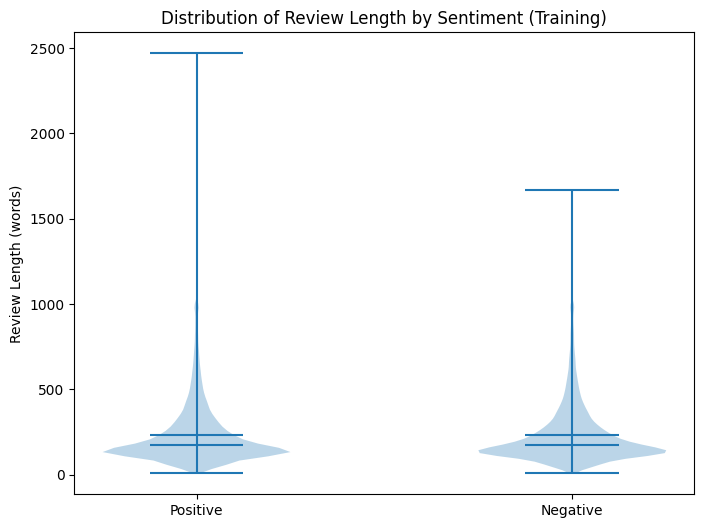

In [14]:
# positive = 1, negative = 0
df_train_positive = df_train[df_train['label'] == 1]['review_length']
df_train_negative = df_train[df_train['label'] == 0]['review_length']

# Combine data into a list
list_train_visualization = [df_train_positive, df_train_negative]

# Create the violin plot
fig, ax = plt.subplots(figsize=(8, 6))
parts = ax.violinplot(list_train_visualization, showmeans=True, showmedians=True)

# Set custom x-tick labels
ax.set_xticks([1, 2])
ax.set_xticklabels(['Positive', 'Negative'])

# Add labels and title
ax.set_ylabel('Review Length (words)')
ax.set_title('Distribution of Review Length by Sentiment (Training)')

plt.show()

As result we can see that:
- Postive reviews have a wider range, extending up to 2500 words compare to Negative only have closely 1500 words.

- According with median we can see each sentiment has almost same distribution.

- Some positive reviewers tends to write very long reivews.


# Generate word frequency distributions.

In [15]:
from collections import Counter

# Obtain positive and negative words from each class
positive_words = [word for tokens in df_train[df_train["label"] == 1]["tokens"] for word in tokens]
negative_words = [word for tokens in df_train[df_train["label"] == 0]["tokens"] for word in tokens]

# Register frequency
positive_freq = Counter(positive_words)
negative_freq = Counter(negative_words)

# Convert to dataframe for visualization
df_positive_freq = pd.DataFrame(positive_freq.most_common(20), columns=['Word', 'Frequency'])
df_negative_freq = pd.DataFrame(negative_freq.most_common(20), columns=['Word', 'Frequency'])

# Display top20 frequent words for each category
print("Top 20 words for positive reviews")
print(df_positive_freq)
print("\nTop 20 words for negative reviews")
print(df_negative_freq)

Top 20 words for positive reviews
      Word  Frequency
0    movie      50011
1     film      46332
2     like      21331
3     good      18619
4     just      17136
5    great      14702
6     time      13346
7    story      13129
8   really      12548
9    films       9996
10  movies       9802
11    best       9580
12    love       9361
13  people       9269
14   watch       9045
15    dont       8581
16   think       8144
17    seen       8057
18     way       8039
19    make       7768

Top 20 words for negative reviews
      Word  Frequency
0    movie      38581
1     film      28128
2     just      14651
3     like      14490
4      bad      12211
5     good       9628
6     time       9235
7   really       8921
8     dont       7858
9    story       7198
10  movies       7014
11  people       6975
12    make       6286
13   watch       6123
14  acting       5768
15   films       5713
16    seen       5645
17    plot       5608
18     way       5479
19   think       5154


Top Frequent Words by Sentiment:

- Positive: movie, good, great, best, love

- Negative: movie, bad, boring, worst, waste

# Create word clouds for positive and negative reviews.

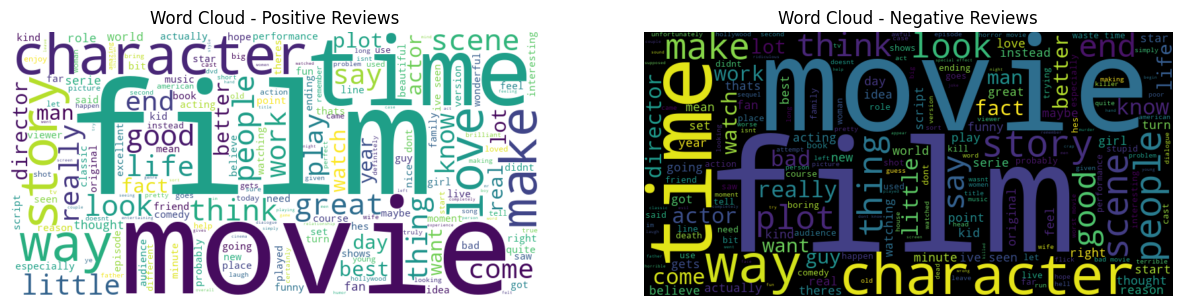

In [16]:
from wordcloud import WordCloud

# Convert words lists to text
positive_text = " ".join(positive_words)
negative_text = " ".join(negative_words)

# Create word clouds
wordcloud_positive = WordCloud(width=800, height=400, background_color="white").generate(positive_text)
wordcloud_negative = WordCloud(width=800, height=400, background_color="black").generate(negative_text)

# Build the plot
fig, ax = plt.subplots(1, 2, figsize=(15,6))

ax[0].imshow(wordcloud_positive, interpolation='bilinear')
ax[0].set_title("Word Cloud - Positive Reviews")
ax[0].axis("off")

ax[1].imshow(wordcloud_negative, interpolation='bilinear')
ax[1].set_title("Word Cloud - Negative Reviews")
ax[1].axis("off")

plt.show()

Word Clouds:

- Clear semantic difference between positive and negative reviews.

- Positive = emotional, descriptive terms like “love”, “great”

- Negative = critical terms like “boring”, “waste”, “bad”

#  Split the dataset

In [17]:
from sklearn.model_selection import train_test_split

df_train_split, df_val_split = train_test_split(
    df_train,
    test_size=0.2,
    stratify=df_train['label'],
    random_state=42
)

# Implement Bag of Words (BoW) feature extraction.​

In [18]:
# Implement BoW feature model
# Convert the the review to numerical data (matrix, vector) based on frequency
BoW_vectorizer = CountVectorizer()
train_review_text = BoW_vectorizer.fit_transform(df_train_split['review'])
test_review_text  = BoW_vectorizer.transform(df_test['review'])
val_review_text = BoW_vectorizer.transform(df_val_split['review'])

# Apply Term Frequency-Inverse Document Frequency (TF-IDF) transformation.​

In [19]:
from sklearn.feature_extraction.text import TfidfTransformer

# Build TF-IDF transformer
tfidf_transformer = TfidfTransformer()

# Apply transformation to data
train_tfidf = tfidf_transformer.fit_transform(train_review_text)
test_tfidf = tfidf_transformer.transform(test_review_text)
val_tfidf = tfidf_transformer.transform(val_review_text)

After implement the BoW and TF-IDF, We can use the data to train a machine Learning model

# Split dataset after TF-IDF 

In [20]:
X_train = train_tfidf
y_train = df_train_split['label']
X_test = test_tfidf
y_test = df_test['label']
X_val = val_tfidf
y_val = df_val_split['label']

# Train baseline models: Logistic Regression and Naive Bayes.​

## Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Set radom_state to 42 to reproduce the result
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train, y_train)


# Use validation data to validate the mode
logistic_predict_val = logistic_model.predict(X_val)
print(classification_report(y_val, logistic_predict_val))
print("Accuracy:", accuracy_score(y_val, logistic_predict_val))

              precision    recall  f1-score   support

           0       0.79      0.70      0.75      5963
           1       0.82      0.88      0.85      9037

    accuracy                           0.81     15000
   macro avg       0.81      0.79      0.80     15000
weighted avg       0.81      0.81      0.81     15000

Accuracy: 0.8089333333333333


## Naive Bayes

In [22]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
# Same process logic as the logistic model
nb_model.fit(X_train, y_train)
nb_predict_val = nb_model.predict(X_val)
print(classification_report(y_val, nb_predict_val))
print("Accuracy:", accuracy_score(y_val, nb_predict_val))

              precision    recall  f1-score   support

           0       0.91      0.16      0.28      5963
           1       0.64      0.99      0.78      9037

    accuracy                           0.66     15000
   macro avg       0.78      0.58      0.53     15000
weighted avg       0.75      0.66      0.58     15000

Accuracy: 0.6616


As a result, the Logistic Regression model has higher accuracy compare to the Naive Bayes model

## Support Vector Machines (SVM)

In [23]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

clf = LinearSVC(random_state=42, max_iter=5000)
clf.fit(X_train, y_train)
clf_predict_val = clf.predict(X_val)

print(classification_report(y_val, clf_predict_val))
print("Accuracy:", accuracy_score(y_val, clf_predict_val))

              precision    recall  f1-score   support

           0       0.77      0.73      0.75      5963
           1       0.83      0.85      0.84      9037

    accuracy                           0.81     15000
   macro avg       0.80      0.79      0.80     15000
weighted avg       0.80      0.81      0.80     15000

Accuracy: 0.8053333333333333


## Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_train)
rf_predict_val = rf_classifier.predict(X_val)

print(classification_report(y_val, rf_predict_val))
print("Accuracy:", accuracy_score(y_val, rf_predict_val))

              precision    recall  f1-score   support

           0       0.79      0.47      0.59      5963
           1       0.73      0.92      0.81      9037

    accuracy                           0.74     15000
   macro avg       0.76      0.70      0.70     15000
weighted avg       0.75      0.74      0.72     15000

Accuracy: 0.7421333333333333


## CNN

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Step 1: Initialize tokenizer
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')  # keep top 20,000 words
tokenizer.fit_on_texts(df_train_split['review'])  # fit on training reviews

# Step 2: Convert reviews to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(df_train_split['review'])
X_val_seq   = tokenizer.texts_to_sequences(df_val_split['review'])
X_test_seq = tokenizer.texts_to_sequences(df_test['review'])


# Step 3: Pad sequences to make them all the same length
X_train_pad = pad_sequences(X_train_seq, maxlen=300, padding='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=300, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=300, padding='post')


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense

model = Sequential([
    Embedding(input_dim=20000, output_dim=64, input_length=300),
    Conv1D(64, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val), epochs=3, batch_size=64)


Epoch 1/3


/opt/anaconda3/envs/nlp/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.6914 - loss: 0.5692 - val_accuracy: 0.7970 - val_loss: 0.4336
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8371 - loss: 0.3667 - val_accuracy: 0.8003 - val_loss: 0.4269
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9127 - loss: 0.2301 - val_accuracy: 0.7913 - val_loss: 0.4923


In [27]:
# Predict on validation or test set
cnn_pred_prob = model.predict(X_test_pad)  # returns probabilities
cnn_pred = (cnn_pred_prob > 0.5).astype(int).reshape(-1)  # convert to 0/1


782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [28]:
print(classification_report(y_test, cnn_pred))
print("Accuracy:", accuracy_score(y_test, cnn_pred))

              precision    recall  f1-score   support

           0       0.81      0.69      0.74     12500
           1       0.73      0.84      0.78     12500

    accuracy                           0.76     25000
   macro avg       0.77      0.76      0.76     25000
weighted avg       0.77      0.76      0.76     25000

Accuracy: 0.76372


# Analyze confusion matrices for each model.

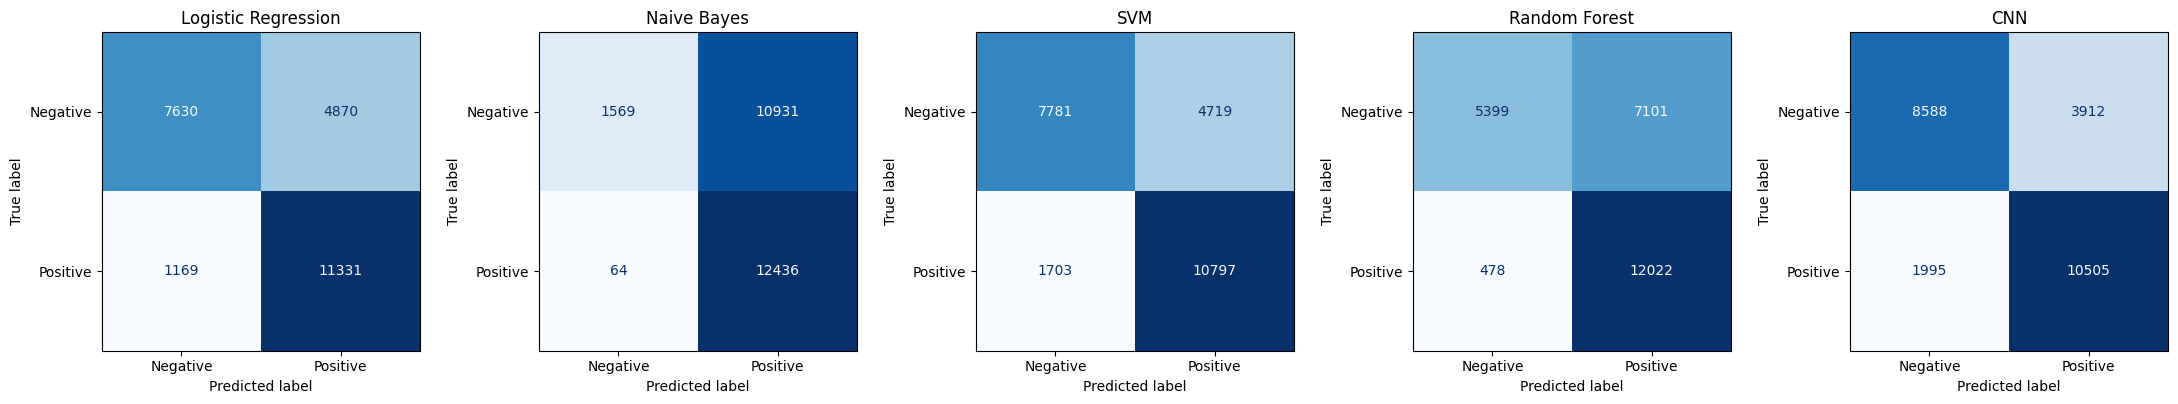

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


logistic_predict_test = logistic_model.predict(X_test)
nb_predict_test = nb_model.predict(X_test)
clf_predict_test = clf.predict(X_test)
rf_predict_test = rf_classifier.predict(X_test)


fig, axs = plt.subplots(1, 5, figsize=(22, 4))

models = {
    "Logistic Regression": logistic_predict_test,
    "Naive Bayes": nb_predict_test,
    "SVM": clf_predict_test,
    "Random Forest": rf_predict_test,
    "CNN": cnn_pred
}

for ax, (name, preds) in zip(axs, models.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


# Analysis F1 score and recall score

## F1 score

In [30]:
from sklearn.metrics import f1_score

print("Logistic Regression:", f1_score(y_test, logistic_predict_test))
print("Naive Bayes:", f1_score(y_test, nb_predict_test))
print("Support Vector Machines:", f1_score(y_test, clf_predict_test))
print("Random Forest:", f1_score(y_test, rf_predict_test))
print("CNN:", f1_score(y_test, cnn_pred))


Logistic Regression: 0.7895892129194104
Naive Bayes: 0.6934508043605543
Support Vector Machines: 0.7707738435179897
Random Forest: 0.760332669259716
CNN: 0.7805476093175316


Based on F1 score, the best model for our data is Logistic Regression

# Analysis accuracy score and precision score

## Accuracy score 

In [31]:
# Accuracy Score
print("Accuracy Score:")
print("Logistic Regression:", accuracy_score(y_test, logistic_predict_test))
print("Naive Bayes:", accuracy_score(y_test, nb_predict_test))
print("Support Vector Machine:", accuracy_score(y_test, clf_predict_test))
print("Random Forest:", accuracy_score(y_test, rf_predict_test))
print("CNN:", accuracy_score(y_test, cnn_pred))


Accuracy Score:
Logistic Regression: 0.75844
Naive Bayes: 0.5602
Support Vector Machine: 0.74312
Random Forest: 0.69684
CNN: 0.76372


## Precision score

In [32]:
from sklearn.metrics import precision_score
print('Precision Score:')
print("Logistic Regression:", precision_score(y_test, logistic_predict_test))
print("Naive Bayes:", precision_score(y_test, nb_predict_test))
print("Support Vector Machine:", precision_score(y_test, clf_predict_test))
print("Random Forest:", precision_score(y_test, rf_predict_test))
print("CNN:", precision_score(y_test, cnn_pred))

Precision Score:
Logistic Regression: 0.6994012715264489
Naive Bayes: 0.5322035348996448
Support Vector Machine: 0.695862335653519
Random Forest: 0.6286670501490352
CNN: 0.728653672747451


Based on the accuracy and precision scores, the best model for our data is still Logistic Regression

# Recall

In [33]:
from sklearn.metrics import recall_score
print('Classification Report:')
print("Logistic Regression:", recall_score(y_test, logistic_predict_test))
print("Naive Bayes:", recall_score(y_test, nb_predict_test))
print("Support Vector Machine:", recall_score(y_test, clf_predict_test))
print("Random Forest:", recall_score(y_test, rf_predict_test))
print("CNN:", recall_score(y_test, cnn_pred))

Classification Report:
Logistic Regression: 0.90648
Naive Bayes: 0.99488
Support Vector Machine: 0.86376
Random Forest: 0.96176
CNN: 0.8404


Based on the recall score, the best model for our data is Naive Bayes.

# Perform hyperparameter tuning for baseline models.​

## Logistic Tuning

In [34]:
from sklearn.model_selection import GridSearchCV

# Example parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],        # Regularization strength
    'penalty': ['l1', 'l2'],        # Norm used in penalization
    'solver': ['liblinear']         # liblinear supports l1 + l2
}

# GridSearchCV with 5-fold CV, optimizing for F1
grid_logreg = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',   # <-- "f1" for cross-validation scoring
    n_jobs=-1
)

# Fit the grid on the training set
grid_logreg.fit(X_train, y_train)

# Identify the best estimator
best_logreg_model = grid_logreg.best_estimator_

# Predict on the test set with the tuned model
logreg_preds = best_logreg_model.predict(X_test)

# --- Evaluate on Test Set ---
print("=== Logistic Regression (Tuned) ===\n")
print("Classification Report on Test Set:")
print(classification_report(y_test, logreg_preds))

# Accuracy and F1 on the test set
test_accuracy = accuracy_score(y_test, logreg_preds)
test_f1 = f1_score(y_test, logreg_preds)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}\n")

# --- Cross-Validation Results (during Grid Search) ---
print("=== Cross-Validation Results ===")
print(f"Best Cross-Val F1 Score: {grid_logreg.best_score_:.4f}")
print("Best Hyperparameters:", grid_logreg.best_params_)

=== Logistic Regression (Tuned) ===

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.87      0.61      0.72     12500
           1       0.70      0.91      0.79     12500

    accuracy                           0.76     25000
   macro avg       0.78      0.76      0.75     25000
weighted avg       0.78      0.76      0.75     25000

Test Accuracy: 0.7586
Test F1 Score: 0.7898

=== Cross-Validation Results ===
Best Cross-Val F1 Score: 0.8423
Best Hyperparameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


## Naive Bayes Tuning

In [35]:
from sklearn.naive_bayes import MultinomialNB
# Define parameter grid for Naive Bayes
param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0]  # Smoothing parameter
}

# GridSearchCV with 5-fold CV, optimizing for accuracy
grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    cv=5,
    scoring='accuracy',  # or 'f1' if that's your priority
    n_jobs=-1
)

# Fit the grid on the training set
grid_nb.fit(X_train, y_train)

# Best estimator from the grid
best_nb_model = grid_nb.best_estimator_

# Predict on the test set
nb_preds = best_nb_model.predict(X_test)

print("=== Naive Bayes (Tuned) ===\n")
print("Classification Report on Test Set:")
print(classification_report(y_test, nb_preds))

# Calculate specific metrics on the test set
test_accuracy = accuracy_score(y_test, nb_preds)
test_f1 = f1_score(y_test, nb_preds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}\n")

# Display cross-validation results from the best model
print("=== Cross-Validation Results ===")
print(f"Best Cross-Val Accuracy: {grid_nb.best_score_:.4f}")  # This is the best average CV score
print("Best Hyperparameters:", grid_nb.best_params_)

=== Naive Bayes (Tuned) ===

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.88      0.52      0.65     12500
           1       0.66      0.93      0.77     12500

    accuracy                           0.72     25000
   macro avg       0.77      0.72      0.71     25000
weighted avg       0.77      0.72      0.71     25000

Test Accuracy: 0.7230
Test F1 Score: 0.7700

=== Cross-Validation Results ===
Best Cross-Val Accuracy: 0.7526
Best Hyperparameters: {'alpha': 0.1}


## SVM Tuning

In [36]:
from sklearn.svm import LinearSVC
# Parameter grid for LinearSVC
param_grid_svm = {
    'C': [0.01, 0.1, 1, 10],
    'loss': ['hinge', 'squared_hinge']
}

# GridSearchCV with 5-fold cross-validation.
# scoring='accuracy' will pick the best hyperparams for accuracy.
# For an F1-optimized model, change to scoring='f1'.
grid_svm = GridSearchCV(
    LinearSVC(random_state=42, max_iter=5000),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit on training set
grid_svm.fit(X_train, y_train)

# Best estimator from the grid
best_svm_model = grid_svm.best_estimator_

# Predict on the test set
svm_preds = best_svm_model.predict(X_test)

print("=== Support Vector Machine (Tuned) ===\n")
print("Classification Report on Test Set:")
print(classification_report(y_test, svm_preds))

# Compute key metrics on the test set
test_accuracy = accuracy_score(y_test, svm_preds)
test_f1 = f1_score(y_test, svm_preds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}\n")

# Display cross-validation results from GridSearchCV
print("=== Cross-Validation Results ===")
print(f"Best Cross-Val Score: {grid_svm.best_score_:.4f}")  # This is accuracy across folds
print("Best Hyperparameters:", grid_svm.best_params_)

=== Support Vector Machine (Tuned) ===

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.84      0.62      0.71     12500
           1       0.70      0.88      0.78     12500

    accuracy                           0.75     25000
   macro avg       0.77      0.75      0.75     25000
weighted avg       0.77      0.75      0.75     25000

Test Accuracy: 0.7503
Test F1 Score: 0.7791

=== Cross-Validation Results ===
Best Cross-Val Score: 0.8017
Best Hyperparameters: {'C': 1, 'loss': 'hinge'}


## Random Forest Tuning

!! It will take about 7 minutes to run this !!

In [40]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Parameter distribution for Random Forest
param_dist_rf = {
    'n_estimators': randint(50, 101),  # allows values between 50 and 100
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

# RandomizedSearchCV with 3-fold cross-validation.
# instead of using GridSearchCV, RandomizedSearchCV run more faster
# Using n_iter=8 ensures we sample from all 8 potential combinations
random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=8,          # there are 2x2x2=8 total combinations, so we sample all
    cv=3,              # reduce CV folds for faster runs
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

print("=== Random Forest (Tuning with RandomizedSearchCV) ===\n")

random_search_rf.fit(X_train, y_train)

print("Best Hyperparameters:")
print(random_search_rf.best_params_)

# Retrieve the best estimator
best_rf_model = random_search_rf.best_estimator_

# Predict on the test set
rf_preds = best_rf_model.predict(X_test)

print("=== Random Forest (Tuned using RandomizedSearchCV) ===\n")
print("Classification Report on Test Set:")
print(classification_report(y_test, rf_preds))

# Compute key metrics on the test set
test_accuracy = accuracy_score(y_test, rf_preds)
test_f1 = f1_score(y_test, rf_preds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}\n")

# Display cross-validation results
print("=== Cross-Validation Results ===")
print(f"Best Cross-Val Score: {random_search_rf.best_score_:.4f}")  # Mean CV score under 'scoring'
print("Best Hyperparameters:", random_search_rf.best_params_)

=== Random Forest (Tuning with RandomizedSearchCV) ===



Best Hyperparameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 88}
=== Random Forest (Tuned using RandomizedSearchCV) ===

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.93      0.42      0.58     12500
           1       0.62      0.97      0.76     12500

    accuracy                           0.69     25000
   macro avg       0.78      0.69      0.67     25000
weighted avg       0.78      0.69      0.67     25000

Test Accuracy: 0.6941
Test F1 Score: 0.7604

=== Cross-Validation Results ===
Best Cross-Val Score: 0.7328
Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 88}


# CNN Optimization

In [38]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define model-building function to be reused with different hyperparams
def create_cnn_model(embedding_dim=64, filters=64, kernel_size=5):
    model = Sequential([
        Embedding(input_dim=20000, output_dim=embedding_dim, input_length=300),
        Conv1D(filters, kernel_size, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(10, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-3), metrics=['accuracy'])
    return model

# 2. Parameter grid
configs = [
    {"embedding_dim": 64, "filters": 64, "kernel_size": 5},
    {"embedding_dim": 128, "filters": 64, "kernel_size": 3},
    {"embedding_dim": 64, "filters": 128, "kernel_size": 3},
    {"embedding_dim": 128, "filters": 128, "kernel_size": 5}
]

# 3. Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# 4. Run training + evaluation for each config
results = []

for i, cfg in enumerate(configs, 1):
    print(f"\n🔧 Config {i}: {cfg}")
    
    model = create_cnn_model(**cfg)
    
    model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=5,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )

    preds = model.predict(X_test_pad)
    preds = (preds > 0.5).astype(int).reshape(-1)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    print(f"✅ Accuracy: {acc:.4f} | F1 Score: {f1:.4f}")
    
    results.append({
        "Config": cfg,
        "Accuracy": acc,
        "F1 Score": f1,
        "Model": model
    })



🔧 Config 1: {'embedding_dim': 64, 'filters': 64, 'kernel_size': 5}


/opt/anaconda3/envs/nlp/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
✅ Accuracy: 0.7621 | F1 Score: 0.7899

🔧 Config 2: {'embedding_dim': 128, 'filters': 64, 'kernel_size': 3}


/opt/anaconda3/envs/nlp/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
✅ Accuracy: 0.7685 | F1 Score: 0.7944

🔧 Config 3: {'embedding_dim': 64, 'filters': 128, 'kernel_size': 3}


/opt/anaconda3/envs/nlp/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
✅ Accuracy: 0.7552 | F1 Score: 0.7855

🔧 Config 4: {'embedding_dim': 128, 'filters': 128, 'kernel_size': 5}


/opt/anaconda3/envs/nlp/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
✅ Accuracy: 0.7614 | F1 Score: 0.7906


We can see an improvement in cnn accuracy with embedding_dim is 64, filters is 64 and kernel_size is 5

# Compare performance metrics across all models

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Collect model names and their predictions on X_test
model_preds = {
    "Logistic Regression (baseline)": logistic_predict_test,
    "Naive Bayes (baseline)":        nb_predict_test,
    "SVM (baseline)":                clf_predict_test,
    "Random Forest (baseline)":      rf_predict_test,
    "CNN (baseline)":                cnn_pred,
    "Logistic Regression (tuned)":   logreg_preds,
    "Naive Bayes (tuned)":           nb_preds,
    "SVM (tuned)":                   svm_preds,
    "Random Forest (tuned)":         rf_preds
    # (If you have optimized CNN configs, add them here too, e.g. "CNN cfg1": preds1, etc.)
}

# 2. Define a helper to compute metrics
def compute_metrics(y_true, y_pred):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),
        "f1":        f1_score(y_true, y_pred)
    }

# 3. Build a DataFrame of results
import pandas as pd

records = []
for name, preds in model_preds.items():
    m = compute_metrics(y_test, preds)
    records.append({
        "Model":    name,
        "Accuracy": m["accuracy"],
        "Precision":m["precision"],
        "Recall":   m["recall"],
        "F1 Score": m["f1"]
    })

results_df = pd.DataFrame.from_records(records)
results_df = results_df.sort_values("F1 Score", ascending=False)  # sort by your primary metric

print("\n=== Comparison of All Models ===")
print(results_df.to_markdown(index=False))


=== Comparison of All Models ===
| Model                          |   Accuracy |   Precision |   Recall |   F1 Score |
|:-------------------------------|-----------:|------------:|---------:|-----------:|
| Logistic Regression (tuned)    |    0.7586  |    0.699377 |  0.90712 |   0.789816 |
| Logistic Regression (baseline) |    0.75844 |    0.699401 |  0.90648 |   0.789589 |
| CNN (baseline)                 |    0.76372 |    0.728654 |  0.8404  |   0.780548 |
| SVM (tuned)                    |    0.75028 |    0.698421 |  0.88096 |   0.779142 |
| SVM (baseline)                 |    0.74312 |    0.695862 |  0.86376 |   0.770774 |
| Naive Bayes (tuned)            |    0.723   |    0.658282 |  0.92744 |   0.770018 |
| Random Forest (tuned)          |    0.69408 |    0.624936 |  0.9708  |   0.760386 |
| Random Forest (baseline)       |    0.69684 |    0.628667 |  0.96176 |   0.760333 |
| Naive Bayes (baseline)         |    0.5602  |    0.532204 |  0.99488 |   0.693451 |
